<a href="https://colab.research.google.com/github/baanujan-18/Statistical-Learning-e20030/blob/main/Assignment_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment_01**

# Q1) The Probability of Shooting at a Target

A point is chosen at random from a disk of radius **10**. Let **A** be the event that the point lies within **1** unit of the boundary.

1. Model the experiment assuming the point is uniformly distributed with respect to area, and compute $P(A)$.

# 1. Uniform Distribution Over Area

Let **A** be the event that the point is located within 1 unit from the boundary of the circle.

Using the radius, this region can be written as:

* Outer limit: $r = R$
* Inner limit: $r = R - 1$

Therefore,

* $$A = \{ r : R - 1 \le r \le R \}$$

Since the point is uniformly distributed over the area,

* Area of sample space:

$$
\text{Area}(\Omega) = \pi R^2
$$

* Area of event:

$$
\text{Area}(A) = \pi R^2 - \pi (R - 1)^2
$$

Now,

$$
P(A) = \frac{\text{Area}(A)}{\text{Area}(\Omega)}
$$

$$
P(A) = \frac{\pi R^2 - \pi (R - 1)^2}{\pi R^2}
$$

$$
P(A) = \frac{2R - 1}{R^2}
$$

Given $R = 10$,

$$
P(A) = \frac{2(10)-1}{10^2}
$$

$$
P(A) = 0.19
$$

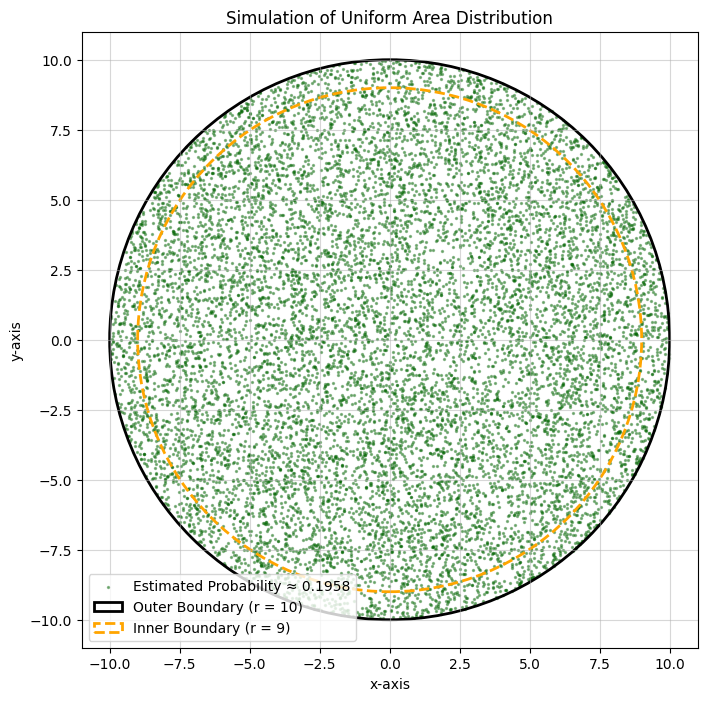

Theoretical Probability = 0.1900
Estimated Probability   = 0.1958


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def area_distribution_simulation(total_points=8000, R=10):

    # Generate random angles
    angles = np.random.uniform(0, 2*np.pi, total_points)

    # Generate radius values for uniform area distribution
    radial_distance = R * np.sqrt(np.random.rand(total_points))

    # Convert polar coordinates into Cartesian coordinates
    x_coord = radial_distance * np.cos(angles)
    y_coord = radial_distance * np.sin(angles)

    # Points lying within 1 unit from the boundary
    boundary_region = radial_distance >= (R - 1)

    # Estimated probability
    estimated_probability = np.mean(boundary_region)

    return x_coord, y_coord, estimated_probability


# Simulation
num_samples = 12000

x_vals, y_vals, estimated_p = area_distribution_simulation(num_samples)

# Plotting
fig, ax = plt.subplots(figsize=(8,8))

scatter_plot = ax.scatter(
    x_vals,
    y_vals,
    s=2,
    alpha=0.4,
    color='darkgreen',
    label=f"Estimated Probability ≈ {estimated_p:.4f}"
)

# Outer circle
outer_circle = plt.Circle(
    (0,0),
    10,
    edgecolor='black',
    fill=False,
    linewidth=2,
    label='Outer Boundary (r = 10)'
)

# Inner circle
inner_circle = plt.Circle(
    (0,0),
    9,
    edgecolor='orange',
    fill=False,
    linestyle='--',
    linewidth=2,
    label='Inner Boundary (r = 9)'
)

ax.add_patch(outer_circle)
ax.add_patch(inner_circle)

ax.set_xlim(-11,11)
ax.set_ylim(-11,11)

ax.set_aspect('equal')

plt.title("Simulation of Uniform Area Distribution")
plt.xlabel("x-axis")
plt.ylabel("y-axis")

plt.grid(alpha=0.5)
plt.legend(loc='lower left')

plt.show()

print(f"Theoretical Probability = 0.1900")
print(f"Estimated Probability   = {estimated_p:.4f}")

## 2. Uniform Distribution with Respect to Radius

In this approach, the radial distance \(r\) is selected uniformly from the interval \([0, R]\), while the angle is chosen independently.  
Therefore, the probability depends on the radial length rather than the area.

* Length of the total sample space:

$$
L(\Omega)=R
$$

* Length corresponding to event \(A\):

$$
L(A)=R-(R-1)
$$

$$
L(A)=1
$$

### Probability Calculation

Using the ratio of lengths,

$$
P(A)=\frac{L(A)}{L(\Omega)}
$$

Substituting the values,

$$
P(A)=\frac{R-(R-1)}{R}
$$

Simplifying,

$$
P(A)=\frac{1}{R}
$$

For the case where \(R=10\),

$$
P(A)=\frac{1}{10}
$$

Therefore,

$$
P(A)=0.1
$$

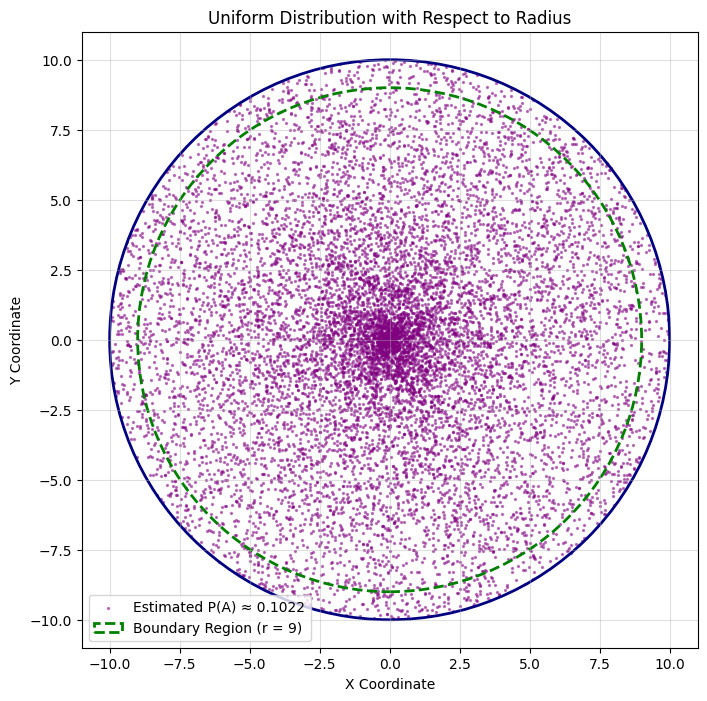

Theoretical Probability = 0.1000
Estimated Probability   = 0.1022


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def radial_distribution_model(sample_size=8000, R=10):

    # Random angle generation
    theta_values = np.random.uniform(0, 2*np.pi, sample_size)

    # Radius selected uniformly from [0, R]
    radius_values = np.random.uniform(0, R, sample_size)

    # Polar to Cartesian conversion
    x_points = radius_values * np.cos(theta_values)
    y_points = radius_values * np.sin(theta_values)

    # Event A : points within 1 unit from the boundary
    event_region = radius_values >= (R - 1)

    # Experimental probability
    probability_estimate = np.mean(event_region)

    return x_points, y_points, probability_estimate


# Run simulation
num_points = 12000

x_data, y_data, estimated_prob = radial_distribution_model(num_points)

# Create figure
fig, ax = plt.subplots(figsize=(8,8))

# Scatter plot
ax.scatter(
    x_data,
    y_data,
    s=2,
    alpha=0.45,
    color='purple',
    label=f"Estimated P(A) ≈ {estimated_prob:.4f}"
)

# Outer boundary
outer_boundary = plt.Circle(
    (0,0),
    10,
    edgecolor='navy',
    fill=False,
    linewidth=2
)

# Inner boundary
inner_boundary = plt.Circle(
    (0,0),
    9,
    edgecolor='green',
    fill=False,
    linestyle='--',
    linewidth=2,
    label='Boundary Region (r = 9)'
)

ax.add_patch(outer_boundary)
ax.add_patch(inner_boundary)

# Axis settings
ax.set_xlim(-11,11)
ax.set_ylim(-11,11)

ax.set_aspect('equal')

plt.title("Uniform Distribution with Respect to Radius")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")

plt.grid(alpha=0.4)
plt.legend(loc='lower left')

plt.show()

print(f"Theoretical Probability = 0.1000")
print(f"Estimated Probability   = {estimated_prob:.4f}")

## 3. Reason for the Difference in Probabilities

The two probability values are different because the points are distributed in two different ways.

In the first model, the points are uniformly distributed over the entire area of the circle. As a result, the points are evenly spread throughout the surface region.

In the second model, the radius is selected uniformly. This causes a larger concentration of points near the center of the circle rather than near the boundary.

The main difference comes from the definition of the underlying measure:

* In Model 1, the distribution is based on **area**
* In Model 2, the distribution is based on **radial distance**

Therefore, when considering the same circular ring near the boundary, the number of points inside that region behaves differently for each model.

* For the area-based model, the number of points changes according to the area of the ring.
* For the radial model, equal radial intervals receive approximately equal numbers of points.

### Conclusion

Both approaches are mathematically valid. However, they represent two different interpretations of what “uniformly distributed” means.